# 07 - Local Volatility and Dupire

# 1. Introduction

## 1.1 Implied Vol Surface → Option Price Surface → Local Vol Surface

This chapter builds a Dupire local volatility surface from market swaption quotes.

We use the Chapter 06 framework:

- `YieldCurve`
- `ForwardStartingSwap`
- `BlackSwaption`

and extend it into a volatility surface framework.

## 1.2 Learning Objectives

By the end of this notebook, we should understand:

1. What an implied volatility surface is
2. How swaption quotes are converted from bp into decimal values
3. How market vols are converted into option prices
4. How Dupire extracts local volatility from option prices
5. Why local vol is not the same as implied vol
6. Why Dupire is numerically unstable
7. Why this chapter is mainly about surface construction, not full local-vol pricing

---

# 2. Import Libraries

In [1]:
import sys
sys.path.append("../python")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from market_data import (
    load_curve_data,
    load_raw_swaption_quotes,
    clean_swaption_quotes,
    build_common_strike_grid
)

from vol_surface import VolSurface
from swaption_price_surface import SwaptionPriceSurface
from dupire_builder import DupireBuilder

from forward_swap import ForwardStartingSwap
from black_swaption import BlackSwaption

plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


---
# 3. Load Market Data

We start with two market data files:

## 3.1 Curve Data

```text
curve_data.csv
```

contains zero rates.

## 3.2 Swaption Vol Surface

```text
swaption_vol_surface.csv
```

contains raw market quotes in basis points:

- `strike_shift_bp`
- `black_vol_bp`

These are converted in `market_data.py`.

This is important because downstream pricing functions should only work with clean decimal values.

In [54]:
curve = load_curve_data("../data/curve_data.csv")

raw_quotes = load_raw_swaption_quotes(
    "../data/swaption_vol_surface.csv"
)

print(raw_quotes.head())

   expiry  tenor  strike_shift_bp  black_vol_bp
0       1      5             -300          3350
1       1      5             -250          3000
2       1      5             -200          2750
3       1      5             -150          2550
4       1      5             -100          2400


---
# 4. Clean Swaption Quotes

Raw quotes are not directly usable for pricing.

The market gives strike shifts in bp:

$$
K = F + \text{strike shift}
$$

where $F$ is the forward swap rate.

For each expiry:

1. Build the corresponding forward-starting swap
2. Compute the forward swap rate from the curve
3. Convert strike shift from bp to decimal
4. Convert Black vol from bp to decimal

The cleaned output contains:

- expiry
- tenor
- forward swap rate
- actual strike
- Black volatility

In [55]:
clean_quotes = clean_swaption_quotes(
    raw_quotes,
    curve,
    target_tenor=5.0
)

clean_quotes.head()

,expiry,tenor,forward_swap_rate,strike_shift_bp,strike,black_vol
0,1.0,5.0,0.044682,-300.0,0.014682,0.335
1,1.0,5.0,0.044682,-250.0,0.019682,0.300
2,1.0,5.0,0.044682,-200.0,0.024682,0.275
3,1.0,5.0,0.044682,-150.0,0.029682,0.255
4,1.0,5.0,0.044682,-100.0,0.034682,0.240


---
# 5. Build a Common Strike Grid

Dupire requires a price surface:

$$
C(T,K)
$$

where the same strike values exist across different expiries.

However, raw swaption quotes are usually quoted as strike shifts around each expiry's forward swap rate.

Because each expiry has a different forward swap rate, the actual strike grids differ by expiry.

Therefore we construct a common strike grid inside the overlapping strike range.

This avoids interpolation errors and makes finite differences in strike meaningful.

In [63]:
common_strikes = build_common_strike_grid(
    clean_quotes,
    num_strikes=10
)

print("Common actual strike grid:")
print(common_strikes)

Common actual strike grid:
[0.01468197 0.02105538 0.02742879 0.0338022  0.04017561 0.04654902
 0.05292243 0.05929584 0.06566925 0.07204266]


# 6. Build the Implied Volatility Surface

The implied volatility surface is:

$$
\sigma_{imp}(T,K)
$$

This is the market input.

It is not produced by Dupire.

It represents the Black implied volatility quoted by the market.

We interpolate it using `LinearNDInterpolator`.

In [64]:
vol_surface = VolSurface(
    clean_quotes,
    common_strikes
)

implied_vol_matrix = vol_surface.vols_from_quotes()

print("Implied Vol Matrix:")
print(implied_vol_matrix)

Implied Vol Matrix:
[[0.335      0.29313295 0.26401272 0.24263931 0.22351908 0.2137341
  0.22648092 0.24384161 0.26993639 0.30416413]
 [0.3448939  0.30448573 0.27609495 0.25545098 0.23633075 0.23019298
  0.2429398  0.26137325 0.28858361 0.32354079]
 [0.35129171 0.31191274 0.28403655 0.26390719 0.24478696 0.24122218
  0.253969   0.27343164 0.3011566  0.33662838]
 [0.3586391  0.32001802 0.29252078 0.27277035 0.25365012 0.25198007
  0.26472689 0.28494742 0.31305132 0.34890205]
 [0.36664577 0.32859421 0.30138173 0.28191607 0.26279584 0.26254959
  0.27544462 0.29608647 0.32447513 0.36061062]
 [0.37904261 0.34173481 0.31492066 0.29580043 0.2766802  0.27829335
  0.29156026 0.31257399 0.34133453 0.3778419 ]
 [0.39222738 0.35543822 0.32914271 0.31002248 0.29090225 0.29381199
  0.30733821 0.32861126 0.35763112 0.3943978 ]
 [0.40726425 0.37046455 0.3441585  0.32503827 0.30591804 0.30880146
  0.32232241 0.34359019 0.37260479 0.40936621]
 [0.41652482 0.37993639 0.35384161 0.33472138 0.31560115 0.31

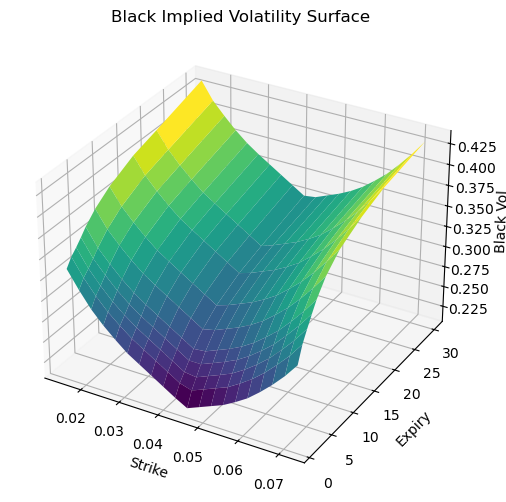

In [58]:
# ============================================================
# Plot implied volatility surface
# ============================================================

from mpl_toolkits.mplot3d import Axes3D

X, Y = np.meshgrid(
    vol_surface.strikes,
    vol_surface.expiries
)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(
    X,
    Y,
    implied_vol_matrix,
    cmap="viridis"
)

ax.set_title("Black Implied Volatility Surface")
ax.set_xlabel("Strike")
ax.set_ylabel("Expiry")
ax.set_zlabel("Black Vol")

plt.show()

---
# 7. From Vol Surface to Price Surface

Dupire does not operate directly on implied volatility.

It operates on option prices:

$$
C(T,K)
$$

Therefore the next step is:

$$
\sigma_{imp}(T,K)
\quad \rightarrow \quad
C(T,K)
$$

For each expiry and strike:

1. Build the forward-starting swap
2. Read interpolated Black vol
3. Price the swaption using Chapter 06 `BlackSwaption`

This gives us a rectangular swaption price surface.

## 7.1 Build swaption price surface

In [67]:
price_surface = SwaptionPriceSurface(
    curve=curve,
    vol_surface=vol_surface,
    tenor=5.0,
    notional=1.0,
    payer=True
)

price_matrix = price_surface.build()

print("Swaption Price Matrix:")
print(price_matrix)

Swaption Price Matrix:
[[0.12696841 0.10005238 0.07350859 0.04851087 0.02727904 0.01277815
  0.00611919 0.00321398 0.00212614 0.00180378]
 [0.11879524 0.0936982  0.06993912 0.04875177 0.03107253 0.01880904
  0.01236237 0.00893735 0.00753209 0.00732019]
 [0.11244731 0.08943729 0.06821903 0.04967412 0.03401996 0.02324507
  0.0173072  0.01410124 0.01291151 0.01313965]
 [0.10739264 0.08640769 0.06734448 0.05081364 0.03662929 0.02704204
  0.02163352 0.01881322 0.01797945 0.01870217]
 [0.10324004 0.08411866 0.06688872 0.0519849  0.03898048 0.03039517
  0.02551791 0.0231024  0.02265264 0.02384366]
 [0.09646285 0.0804319  0.06605328 0.05358974 0.04239035 0.03538389
  0.03147766 0.02980941 0.03006537 0.0320221 ]
 [0.0881188  0.07552918 0.06420988 0.05427866 0.04506608 0.03973345
  0.03695492 0.0361671  0.03718434 0.03984713]
 [0.07614    0.06739508 0.05941686 0.05231003 0.04545875 0.0418197
  0.04025266 0.04033076 0.04194662 0.04496607]
 [0.06472798 0.05853742 0.05281004 0.04763226 0.04249716 0

## 7.2 Plot price surface

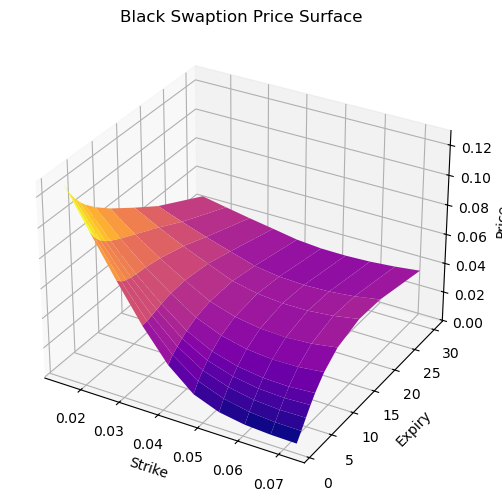

In [68]:
X, Y = np.meshgrid(
    price_surface.strikes,
    price_surface.expiries
)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(
    X,
    Y,
    price_matrix,
    cmap="plasma"
)

ax.set_title("Black Swaption Price Surface")
ax.set_xlabel("Strike")
ax.set_ylabel("Expiry")
ax.set_zlabel("Price")

plt.show()

---
# 8. Dupire Local Volatility

Dupire's formula extracts local volatility from the option price surface:

$$
\sigma_{loc}^2(K,T) = \frac{\frac{\partial C}{\partial T}}{\frac12 K^2\frac{\partial^2 C}{\partial K^2}}
$$

where:

- $\frac{\partial C}{\partial T}$ measures how option value changes with expiry
- $\frac{\partial^2 C}{\partial K^2}$ measures strike convexity
- $ K^2 $ comes from lognormal local volatility dynamics

Important:

Dupire is numerically sensitive because it requires derivatives of market prices.

Small noise in prices can create large noise in local volatility.

## 8.1 Build Dupire local volatility surface

In [69]:
dupire = DupireBuilder(
    price_surface
)

local_surface = dupire.build()

print("Local Vol Matrix:")
print(local_surface.local_vol_matrix)

Local Vol Matrix:
[[       nan        nan        nan        nan        nan        nan
         nan        nan        nan        nan]
 [       nan        nan        nan 0.10857414 0.17698616 0.18366568
  0.23173226 0.24954981 0.29177001        nan]
 [       nan        nan        nan 0.1592397  0.16929447 0.17862854
  0.22185359 0.2378835  0.26344879        nan]
 [       nan        nan        nan 0.18710938 0.16479005 0.17909996
  0.21449758 0.22879604 0.2427959         nan]
 [       nan        nan        nan 0.18611907 0.14789304 0.16767726
  0.1966319  0.20756655 0.21507012        nan]
 [       nan        nan        nan 0.1606323  0.12087388 0.15028915
  0.17218306 0.17713304 0.17942254        nan]
 [       nan        nan        nan        nan 0.07053786 0.1086711
  0.1264216  0.12975003 0.13039343        nan]
 [       nan        nan        nan        nan        nan 0.02418837
  0.06353597 0.07349864 0.07632561        nan]
 [       nan        nan        nan        nan        nan       

## 8.2 Why Are Boundary Values NaN?

The local volatility matrix contains `NaN` values on the boundary.

This is expected.

Dupire uses central finite differences:

$$
\frac{\partial C}{\partial T}
$$

requires expiry points before and after the current expiry.

$$
\frac{\partial^2 C}{\partial K^2}
$$

requires strike points to the left and right.

Therefore:

- first expiry row cannot be computed
- last expiry row cannot be computed
- first strike column cannot be computed
- last strike column cannot be computed

This is a numerical feature, not necessarily a bug.

## 8.3 Count valid local vol points

In [71]:
# ============================================================
# Cell 12 — Count valid local vol points
# ============================================================

finite_local_vols = local_surface.local_vol_matrix[
    ~np.isnan(local_surface.local_vol_matrix)
]

print("Number of finite local vol points:", len(finite_local_vols))
print("Min local vol:", finite_local_vols.min())
print("Max local vol:", finite_local_vols.max())
print("Mean local vol:", finite_local_vols.mean())

Number of finite local vol points: 39
Min local vol: 0.02418837109640435
Max local vol: 0.2917700095489657
Mean local vol: 0.16857769333514117


## 8.4 Plot local volatility surface

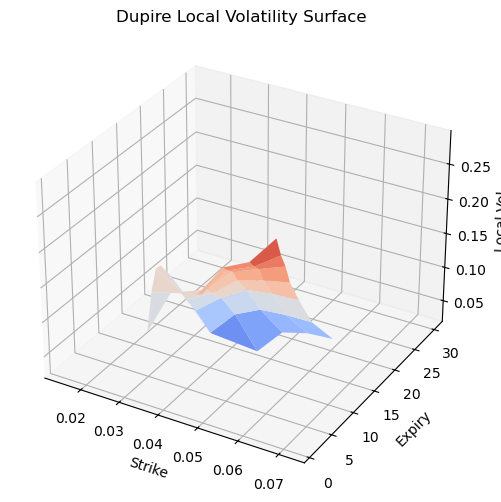

In [70]:
X, Y = np.meshgrid(
    local_surface.strikes,
    local_surface.expiries
)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(
    X,
    Y,
    local_surface.local_vol_matrix,
    cmap="coolwarm"
)

ax.set_title("Dupire Local Volatility Surface")
ax.set_xlabel("Strike")
ax.set_ylabel("Expiry")
ax.set_zlabel("Local Vol")

plt.show()

## 8.5 Why Is the Local Volatility Surface Less Smooth?

In the previous plots, the implied volatility surface and the Black swaption price surface look relatively smooth.

However, after applying Dupire's formula, the local volatility surface may become much less smooth.

This is expected and is one of the main practical challenges of local volatility modelling.

### Implied Volatility Surface

The implied volatility surface is directly built from market quotes:

$$
\sigma_{imp}(T,K)
$$

In this notebook, the input volatility quotes are deliberately constructed to be smooth across expiry and strike.

As a result, the implied volatility surface looks visually stable.

### Black Price Surface

The Black price surface is obtained by applying the Black formula to the implied volatility surface:

$$
\sigma_{imp}(T,K)
\rightarrow
C(T,K)
$$

The Black formula is a smooth nonlinear transformation.

Therefore, if the implied volatility surface is smooth, the price surface will usually also look smooth.

### Dupire Local Volatility Surface

Dupire's formula is different.

It requires numerical derivatives of the price surface:

$$
\sigma_{loc}^{2}(T,K) = \frac{\frac{\partial C}{\partial T}}{\frac12 K^2\frac{\partial^2 C}{\partial K^2}
}
$$

This means local volatility depends on:

- the first derivative of price with respect to expiry
- the second derivative of price with respect to strike

Numerical derivatives amplify small changes in the price surface.

Even if \(C(T,K)\) looks smooth visually, its finite-difference derivatives can still be noisy.

### Why Noise Is Amplified

The denominator contains:

$$
\frac{\partial^2 C}{\partial K^2}
$$

If this strike convexity is small, then the denominator becomes very small.

A small denominator can make the local volatility value unstable or extremely large.

This is why local volatility surfaces often look rougher than implied volatility surfaces.

### Practical Quant Implication

In production systems, raw Dupire local volatility surfaces are rarely used directly without treatment.

Common stabilisation techniques include:

- smoothing the implied volatility surface before applying Dupire
- enforcing no-arbitrage constraints
- using monotone interpolation
- regularising finite differences
- filtering unstable wing points
- using parametric models such as SABR


### Key Takeaway

A smooth implied volatility surface does not automatically imply a smooth local volatility surface.

The transformation:

```text
Implied Vol Surface
        ↓
Black Price Surface
        ↓
Numerical Derivatives
        ↓
Local Vol Surface
```

can amplify small numerical effects.

This is why Dupire local volatility is powerful but numerically fragile.

---
# 9. Implied Vol vs Local Vol

## 9.1 Concepts

Implied volatility and local volatility are not the same object.

### Implied Volatility

$$
\sigma_{imp}(T,K)
$$

is the volatility that makes Black's formula match a market price.

It is a quoting convention.

### Local Volatility

$$
\sigma_{loc}(T,K)
$$

is the instantaneous volatility in a model:

$$
dF_t = \sigma_{loc}(t,F_t) F_t dW_t
$$

It is a model input derived from the full option price surface.

### Key Difference

Implied vol is observed from market prices.

Local vol is inferred from the shape and derivatives of the entire price surface.

## 9.2 Compare implied vol and local vol at valid points

In [72]:
print("Implied Vol Matrix:")
print(implied_vol_matrix)

print("\nLocal Vol Matrix:")
print(local_surface.local_vol_matrix)

Implied Vol Matrix:
[[0.335      0.29313295 0.26401272 0.24263931 0.22351908 0.2137341
  0.22648092 0.24384161 0.26993639 0.30416413]
 [0.3448939  0.30448573 0.27609495 0.25545098 0.23633075 0.23019298
  0.2429398  0.26137325 0.28858361 0.32354079]
 [0.35129171 0.31191274 0.28403655 0.26390719 0.24478696 0.24122218
  0.253969   0.27343164 0.3011566  0.33662838]
 [0.3586391  0.32001802 0.29252078 0.27277035 0.25365012 0.25198007
  0.26472689 0.28494742 0.31305132 0.34890205]
 [0.36664577 0.32859421 0.30138173 0.28191607 0.26279584 0.26254959
  0.27544462 0.29608647 0.32447513 0.36061062]
 [0.37904261 0.34173481 0.31492066 0.29580043 0.2766802  0.27829335
  0.29156026 0.31257399 0.34133453 0.3778419 ]
 [0.39222738 0.35543822 0.32914271 0.31002248 0.29090225 0.29381199
  0.30733821 0.32861126 0.35763112 0.3943978 ]
 [0.40726425 0.37046455 0.3441585  0.32503827 0.30591804 0.30880146
  0.32232241 0.34359019 0.37260479 0.40936621]
 [0.41652482 0.37993639 0.35384161 0.33472138 0.31560115 0.31

---
# 10. Interpolating Local Vol at an Off-Grid Point

The local volatility surface is useful because we can ask:

$$
\sigma_{loc}(T,K)
$$

for non-standard expiries and strikes.

For example:

- expiry = 4Y
- strike not exactly quoted in the market grid

This is why `LocalVolSurface` uses `LinearNDInterpolator`.

Important:

This interpolation is only valid inside the region supported by finite Dupire local vol values.

In [73]:
# ============================================================
# Off-grid local vol interpolation
# ============================================================

# Pick an off-grid point that is inside the interpolation region.
# The exact value may depend on the valid Dupire grid.

off_grid_expiry = 4.0
off_grid_strike = 0.046876634377547535

try:
    off_grid_local_vol = local_surface.get_local_vol(
        off_grid_expiry,
        off_grid_strike
    )

    print("Off-grid expiry:", off_grid_expiry)
    print("Off-grid strike:", off_grid_strike)
    print("Interpolated local vol:", off_grid_local_vol)

except Exception as e:
    print("Interpolation failed:")
    print(e)

Off-grid expiry: 4.0
Off-grid strike: 0.046876634377547535
Interpolated local vol: 0.1809195157277033


The off-grid point represents a hypothetical swaption
with an expiry and strike not directly quoted in the market.

It is used to demonstrate interpolation on the Dupire
local volatility surface.

The coordinates correspond to:

    Expiry = option maturity

    Strike = swaption strike

rather than a future simulation time and realized swap rate.

---
# 11 Interpolation Methods and Cross-Language Validation

When validating the C++ implementation against the Python implementation,
we observed that the interpolated local volatility values may not always identical, although using the data above lead to the same result.

At first glance this may appear to indicate a coding error. However,
the discrepancy is explained by the interpolation method.

## 11.1 Why Does This Happen?

The local volatility surface is only known at a finite set of grid points:

$$
\sigma_{loc}(T_i,K_j)
$$

When we request a value at an off-grid point:

$$
\sigma_{loc}(T,K)
$$

an interpolation scheme must be used.

Different interpolation methods construct different approximations
to the unknown surface.

## 11.2 Python: LinearNDInterpolator

The Python implementation uses:

```python
LinearNDInterpolator
```

from SciPy.

This method:

1. Constructs a Delaunay triangulation
2. Splits the surface into triangles
3. Performs piecewise linear interpolation

Conceptually:

```text
Known Points
     ↓
Triangulation
     ↓
Linear interpolation inside each triangle
```

Advantages:

- Handles irregular grids naturally
- Works even when some surface points are missing
- Commonly used in rapid prototyping

Disadvantages:

- More difficult to replicate exactly in C++
- Results depend on triangulation geometry

## 11.3 Manual: Bilinear Interpolation

The manual implementation uses bilinear interpolation.

For a query point inside a rectangular cell:

```text
Q11 ----- Q12
 |         |
 |    x    |
 |         |
Q21 ----- Q22
```

the value is computed as a weighted average of the four corner values.

Advantages:

- Simple
- Fast
- Deterministic
- Easy to audit and debug

Disadvantages:

- Assumes a rectangular grid
- Less flexible for sparse surfaces


In [74]:
def bilinear_local_vol(local_surface, expiry, strike):

    expiries = local_surface.expiries
    strikes = local_surface.strikes
    vols = local_surface.local_vol_matrix

    i = np.searchsorted(expiries, expiry)
    j = np.searchsorted(strikes, strike)

    i = max(1, min(i, len(expiries) - 1))
    j = max(1, min(j, len(strikes) - 1))

    T1, T2 = expiries[i-1], expiries[i]
    K1, K2 = strikes[j-1], strikes[j]

    Q11 = vols[i-1, j-1]
    Q12 = vols[i-1, j]
    Q21 = vols[i, j-1]
    Q22 = vols[i, j]

    print("Corners:", Q11, Q12, Q21, Q22)

    wtT = (expiry - T1) / (T2 - T1)
    wtK = (strike - K1) / (K2 - K1)

    return (
        (1-wtT)*(1-wtK)*Q11
        + (1-wtT)*wtK*Q12
        + wtT*(1-wtK)*Q21
        + wtT*wtK*Q22
    )

In [75]:
bilinear_value = bilinear_local_vol(
    local_surface,
    4.0,
    0.046876634377547535
)

linear_nd_value = local_surface.get_local_vol(
    4.0,
    0.046876634377547535
)

print("Python bilinear:", bilinear_value)
print("Python LinearND:", linear_nd_value)

Corners: 0.1786285412054832 0.22185358525870189 0.17909995829260347 0.2144975798608223
Python bilinear: 0.1809195157277033
Python LinearND: 0.1809195157277033



## 11.5 Practical Quant Perspective

This example illustrates an important lesson in quantitative development:

> Numerical implementation details can matter as much as the model itself.

In practice, two systems may:

- use the same market data
- use the same mathematical model
- use the same calibration procedure

and still produce slightly different outputs because of:

- interpolation choices
- finite difference schemes
- numerical tolerances
- extrapolation rules

Consequently, model validation often focuses not only on the theoretical model,
but also on the numerical implementation.

For production systems, interpolation methodology should be explicitly documented
and consistently implemented across platforms.

---

# 12 From Market Quotes to Stochastic Dynamics

One of the most important conceptual steps in local volatility modelling is understanding how a surface defined in market quote space becomes a volatility function used inside a stochastic process.

## Step 1: Market Quote Space

Market swaption quotes are observed as a function of:

$$
(T,K)
$$

where:

- $T$ = option expiry
- $K$ = strike

For example:

| Expiry | Strike | Market Black Vol |
|----------|----------|----------|
| 1Y | 4.0% | 1100bp |
| 5Y | 4.0% | 1500bp |
| 10Y | 4.0% | 1850bp |

These market observations define the implied volatility surface:

$$
\sigma_{imp}(T,K)
$$

Using Black's model, we convert the implied volatility surface into an option price surface:

$$
C(T,K)
$$

Dupire's formula then produces the local volatility surface:

$$
\sigma_{loc}(T,K)
$$

At this stage, the surface still lives entirely in quote space.

## Step 2: Local Volatility Model

The local volatility model assumes that the forward swap rate evolves according to:

$$
dF_t = \sigma_{loc}(t,F_t) \,F_t\,dW_t
$$

Unlike Black's model, volatility is no longer constant.

Instead, volatility depends on:

- current simulation time \(t\)
- current forward swap rate level \(F_t\)

## Step 3: Connecting the Two Views

At first sight, the two surfaces appear different:

Quote Space:

$$
\sigma_{loc}(T,K)
$$

Simulation Space:

$$
\sigma_{loc}(t,F_t)
$$

However, they are actually the same object.

The strike variable $K$ used during calibration becomes the state variable $F_t$ during simulation.

Conceptually:

```text
Market Quotes
        ↓
σloc(T,K)
        ↓
Calibration Complete
        ↓
Monte Carlo Simulation
        ↓
σloc(t,Ft)
```

The surface is simply being viewed from two different perspectives.

## Example

Suppose Dupire calibration produces:

$$
\sigma_{loc}(5,\;4\%) = 25\%
$$

This means:

```text
Expiry = 5 years
Strike = 4%
```

was associated with a local volatility of 25%.

Later, during a Monte Carlo simulation, one path reaches:

$$
t=5
$$

and

$$
F_t=4\%
$$

At that moment the simulation will query:

$$
\sigma_{loc}(5,\;4\%)
$$

and obtain:

$$
25\%
$$

The exact same surface value that was previously calibrated from market option prices.

## Why This Matters

This observation explains why Dupire local volatility perfectly reproduces the market vanilla option surface.

The model is calibrated so that every point on the local volatility surface is consistent with observed market option prices.

As a result:

- calibration is performed in quote space $(T,K)$
- simulation is performed in state space $(t,F_t)$

but both use the same local volatility function.

Understanding this connection is one of the key conceptual steps in moving from option market data to stochastic volatility modelling.

---
# 13. Diagnostic Off-Grid Pricing

We can reuse the interpolated local volatility as an effective Black volatility.

This is only a diagnostic approximation.

It is not full local volatility pricing.

True local-vol pricing requires either:

- Monte Carlo simulation
- finite difference PDE
- tree methods

Those are addressed later in the library.

Here we only verify that:

$$
\sigma_{loc}(T,K)
$$

can be interpolated and passed into a pricing engine.

In [76]:
# ============================================================
# Diagnostic pricing using interpolated local vol
# ============================================================

underlying_swap = ForwardStartingSwap(
    notional=1.0,
    fixed_rate=None,
    start=off_grid_expiry,
    end=off_grid_expiry + 5.0,
    payment_frequency=2
)

forward_swap_rate = underlying_swap.forward_swap_rate(
    curve
)

print("Forward swap rate:", forward_swap_rate)
print("Moneyness F-K:", forward_swap_rate - off_grid_strike)

diagnostic_swaption = BlackSwaption(
    notional=1_000_000,
    strike=off_grid_strike,
    expiry=off_grid_expiry,
    underlying_swap=underlying_swap,
    volatility=off_grid_local_vol,
    payer=True
)

diagnostic_price = diagnostic_swaption.price(
    curve
)

print("Diagnostic price:", diagnostic_price)

Forward swap rate: 0.043058984589800314
Moneyness F-K: -0.003817649787747221
Diagnostic price: 17559.022653076503


---
# 14. Why Can the Diagnostic Price Can Be Very Small?

If the selected strike is far above the forward swap rate, the payer swaption becomes deep out-of-the-money.

For example:

$$
F < K
$$

and if the volatility is low, the probability of finishing in the money becomes very small.

Therefore the diagnostic price can be close to zero.

This does not mean the Dupire surface is wrong.

It only means the selected off-grid swaption is far out-of-the-money.

The main purpose of this diagnostic is to check that:

- local vol interpolation works
- the workflow is connected
- the pricing engine accepts the interpolated vol

not to validate a full local-vol pricing engine.

---
# 15. Numerical Stability of Dupire

Dupire local volatility is highly sensitive because it depends on derivatives:

$$
\frac{\partial C}{\partial T}
$$

and

$$
\frac{\partial^2 C}{\partial K^2}
$$

This means noisy market prices can produce unstable local volatility.

Common production treatments include:

- smoothing implied volatility surfaces
- enforcing no-arbitrage constraints
- using monotone interpolation
- filtering unstable wings
- regularizing finite differences

This is one reason why SABR models are often preferred for rates smile modeling.

---
# 16. Summary

In this chapter we built:

- cleaned swaption market quotes
- Black implied volatility surface
- swaption price surface
- Dupire local volatility surface
- off-grid local vol interpolation
- diagnostic off-grid pricing

This chapter is about **surface construction**, not full exotic pricing.

The workflow is:

```text
Market swaption vol quotes
        ↓
Cleaned implied vol surface
        ↓
Black swaption price surface
        ↓
Dupire finite differences
        ↓
Local volatility surface
```

## Key Lessons

1. Implied vol is market-quoted.
2. Local vol is model-implied.
3. Dupire requires option price derivatives.
4. Numerical stability is difficult.
5. Boundary NaNs are expected with central differences.
6. Full local-vol pricing requires PDE or Monte Carlo.

## Quant Insight:

- local vol explains the smile through state-dependent volatility
- Dupire connects option prices to a model surface
- surface quality matters more than formula memorization
- numerical stability is critical in production systems

A good quant must understand not only the formula, but also why the implementation is fragile.

## Next Chapter

### Chapter 08: SABR Volatility Surface Calibration

We will move from local volatility to stochastic volatility.

Topics include:

- SABR dynamics
- smile generation
- skew modeling
- parameter calibration
- swaption vol surface fitting